# 01 · Current status of data centers and the grid in California

Chapter 1 of *Mapping the Consumption Gap*. Answers "how much of the state's power do data centers use" and builds the grid baseline from Section 3.2 of the proposal.

All numbers come from `data/raw` through `src/ch1_baseline.py`; `scripts/run_chapter1.py` writes the tables (`data/processed/ch1_*`) and figures (`figures/fig1_*`) that this notebook displays. Every table names the manifest `source_id` it was built from.

| Step | Sources (manifest ids) |
|---|---|
| 1. Hourly demand, generation by fuel, interchange, 2019-2025 | `eia930_balance_*` (Adjusted series), cross-checked against `caiso_outlook_demand` |
| 2. Day-ahead price duration curves, negative-price hours | `caiso_dam_lmp_monthly_dlap`, `caiso_dam_lmp_monthly_hubs`, `eia_ice_wholesale_*` |
| 3. Hourly carbon intensity | `caiso_outlook_co2`, `caiso_outlook_demand`, `epa_egrid2023_rev1` |
| 4. Existing data center load, four ways | `epri_powering_intelligence_2024`, `cec_dc_methodology_memo_2026`, `kollar_grady_2025_zenodo`, `epoch_data_centers`, `svp_*`, `eia861_2024` |
| 5. Institutional context | `cec_tn268288`, `cec_tn269506`, `cec_tn261964`, `cec_tn261975`, `cec_tn268459`, `pge_*`, `cpuc_oir_rate_design_2026_04`, `ca_sb57_*`, `ca_sb886_*`, `ca_ab222_*`, `cpuc_news_streamlined_connections` |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw)
rec = json.loads((PROCESSED / "ch1_run_record.json").read_text()); rec

{'years': [2019, 2020, 2021, 2022, 2023, 2024, 2025],
 'ciso_hours': 61368,
 'ciso_valid_demand_hours': {'2019': 8435,
  '2020': 8783,
  '2021': 8760,
  '2022': 8760,
  '2023': 8759,
  '2024': 8757,
  '2025': 8743},
 'lmp_hours': 28320,
 'co2_valid_hours': {'2019': 8759,
  '2020': 8782,
  '2021': 8759,
  '2022': 8759,
  '2023': 8759,
  '2024': 8765,
  '2025': 8759},
 'retail_sales_2024_TWh': 245.717145,
 'retail_sales_2023_TWh': 239.480452,
 'kollar_grady_california_points': 321,
 'outputs': ['ch1_battery_summary.csv',
  'ch1_bottom_up_inputs.json',
  'ch1_ca_retail_sales_eia861.csv',
  'ch1_carbon_intensity_annual.csv',
  'ch1_carbon_intensity_diurnal.csv',
  'ch1_carbon_intensity_duration.csv',
  'ch1_ciso_annual_summary.csv',
  'ch1_dc_load_estimates.csv',
  'ch1_egrid_camx_2023.json',
  'ch1_eia930_fill_log.csv',
  'ch1_eia930_flagged_hours.csv',
  'ch1_gas_series_comparability_monthly.csv',
  'ch1_ice_daily_hub_prices_negative_days.csv',
  'ch1_kollar_grady_points_california_flag.

## 1. Grid baseline: CAISO hourly demand, net load, imports (EIA-930, 2019-2025)

EIA-930 "Adjusted" series for the CISO balancing authority. Net load = demand − utility-scale solar − wind. Imports = −net interchange. EIA-930's CISO demand includes storage charging and pumping load, whereas CAISO's Today's Outlook 'Current demand' excludes charging; in 2025 the gap between the two tracks battery charging almost one-for-one. Both are kept: `demand` (EIA definition) and `demand_ex_storage` (EIA demand minus CAISO-reported charging). Hours where EIA demand is implausibly low (below 85 percent of CAISO demand plus charging, or under 5 GW) are reporting artifacts and are nulled (listed in `ch1_eia930_flagged_hours.csv`). EIA-930 has no CISO interchange in any variant from 2024-07-02 to 2024-11-03 and no hydro for parts of 2019-2020; those hours are filled from CAISO's five-minute imports and hydro series via a per-year linear calibration (`ch1_eia930_fill_log.csv`).

In [2]:
summ = table("ch1_ciso_annual_summary", index_col=0)
cols = ["hours","energy_TWh","avg_demand_MW","peak_demand_MW","peak_demand_time","load_factor","peak_net_load_MW","peak_net_load_time","min_net_load_MW","min_net_load_ex_storage_MW","storage_charging_TWh","solar_TWh","wind_TWh","gas_TWh","net_imports_TWh","import_share_of_demand","solar_wind_share_of_demand"]
summ[cols].round(3)

,hours,energy_TWh,avg_demand_MW,peak_demand_MW,peak_demand_time,load_factor,peak_net_load_MW,peak_net_load_time,min_net_load_MW,min_net_load_ex_storage_MW,storage_charging_TWh,solar_TWh,wind_TWh,gas_TWh,net_imports_TWh,import_share_of_demand,solar_wind_share_of_demand
year,,,,,,,,,,,,,,,,,
2019,8435,215.848,24640.228,43849.0,2019-08-15 18:00:00-07:00,0.562,40536.0,2019-08-14 19:00:00-07:00,5249.0,5247.167,0.076,27.713,15.878,65.244,53.827,0.249,0.202
2020,8783,217.989,24816.572,46643.0,2020-08-18 16:00:00-07:00,0.532,44026.0,2020-09-05 19:00:00-07:00,5553.0,5537.500,0.081,28.644,14.939,73.834,59.390,0.272,0.200
2021,8760,219.186,25021.244,43615.0,2021-09-08 18:00:00-07:00,0.574,40495.0,2021-09-08 19:00:00-07:00,3021.0,2943.083,0.915,32.753,18.303,79.288,54.472,0.249,0.233
2022,8760,223.662,25532.245,51104.0,2022-09-06 18:00:00-07:00,0.500,47464.0,2022-09-06 19:00:00-07:00,1938.0,1770.750,1.702,35.828,17.384,82.796,48.672,0.218,0.238
2023,8759,218.179,24906.333,44007.0,2023-08-16 19:00:00-07:00,0.566,41764.0,2023-08-15 20:00:00-07:00,1658.0,922.417,4.450,37.168,16.404,88.015,28.849,0.132,0.246
2024,8757,224.052,25506.882,47571.0,2024-09-05 19:00:00-07:00,0.536,42403.0,2024-09-05 21:00:00-07:00,253.0,-2153.750,9.451,44.836,20.119,85.537,31.708,0.142,0.290
2025,8743,224.075,25579.368,43860.0,2025-08-21 20:00:00-07:00,0.583,39787.0,2025-08-21 21:00:00-07:00,-3255.0,-4960.083,14.214,49.650,19.814,79.013,36.091,0.161,0.310


In [3]:
table("ch1_eia930_flagged_hours", index_col=0)

,demand,solar,wind,net_load,caiso_demand
hour_ending_local,,,,,
2019-02-05 11:00:00-08:00,18400.0,6297.0,2753.0,9350.0,24543.166667
2019-02-05 14:00:00-08:00,17037.0,5228.0,2355.0,9454.0,23283.416667
2019-02-05 18:00:00-08:00,23019.0,-34.0,2034.0,21019.0,27119.500000
2019-02-05 19:00:00-08:00,23943.0,-34.0,2766.0,21211.0,29028.166667
2019-02-05 20:00:00-08:00,23945.0,-34.0,2350.0,21629.0,28898.250000
...,...,...,...,...,...
2025-11-01 13:00:00-07:00,16016.0,15958.0,746.0,-688.0,22528.083333
2025-11-01 14:00:00-07:00,16391.0,15798.0,748.0,-155.0,23149.333333
2025-11-01 15:00:00-07:00,17834.0,15563.0,728.0,1543.0,24301.666667


In [4]:
table("ch1_eia930_fill_log").round(3)

,year,target,n_missing,n_filled,slope,intercept,corr
0,2019,imports,0,0,NaN,NaN,NaN
1,2020,imports,0,0,NaN,NaN,NaN
2,2021,imports,24,24,0.905,1005.641,0.995
3,2022,imports,0,0,NaN,NaN,NaN
4,2023,imports,96,96,0.907,811.806,0.995
5,2024,imports,2232,2229,0.898,915.200,0.986
6,2025,imports,48,48,0.799,1292.205,0.987
7,2019,hydro,2196,2194,0.877,446.463,0.919
8,2020,hydro,5675,5675,0.948,77.476,0.942
9,2021,hydro,0,0,NaN,NaN,NaN


**Data quality.** Valid demand hours per year are in `hours`; 2019 has 325 missing hours (3.7 percent) after the artifact filter, later years at most 27. Annual energy = mean of valid hours x calendar hours (missing hours imputed at the annual mean); duration curves and profiles use valid hours only. EIA-930's CISO natural gas series changed method in December 2023 (EIA warning): it matches CAISO's own fuel mix within 0.1 TWh a month through November 2023 and exceeds it by 0.7-1.8 TWh a month afterwards, so gas columns must not be compared across that date.

In [5]:
table("ch1_gas_series_comparability_monthly", index_col=0).loc["2023-08-01":"2024-04-01"].round(2)

,eia930_gas_TWh,caiso_fuelmix_gas_TWh,caiso_gas_co2_Mt,caiso_demand_TWh,co2_accounting_g_per_kWh,implied_gas_kg_per_MWh,eia_minus_caiso_gas_TWh
2023-08-01,10.07,10.06,4.47,22.19,256.72,444.60,0.00
2023-09-01,7.09,7.09,3.12,18.63,232.19,439.90,0.00
2023-10-01,9.05,9.06,4.00,17.85,279.83,440.93,-0.01
2023-11-01,8.05,7.97,3.49,16.35,280.50,438.23,0.08
2023-12-01,8.94,8.25,3.57,17.24,278.46,432.35,0.69
2024-01-01,9.20,7.94,3.49,16.60,251.78,439.03,1.26
2024-02-01,6.34,5.14,2.26,15.27,220.64,440.10,1.21
2024-03-01,4.85,3.36,1.48,15.34,161.08,440.24,1.49
2024-04-01,4.49,2.71,1.22,14.59,141.76,452.19,1.78


**Reading.** CAISO annual demand has been flat at roughly 214-224 TWh since 2019 while utility-scale solar and wind rose from a fifth to nearly a third of demand and net imports fell from a quarter of demand to 13-16 percent (2023-2025). The hourly peak record remains September 6, 2022 (51.1 GW).

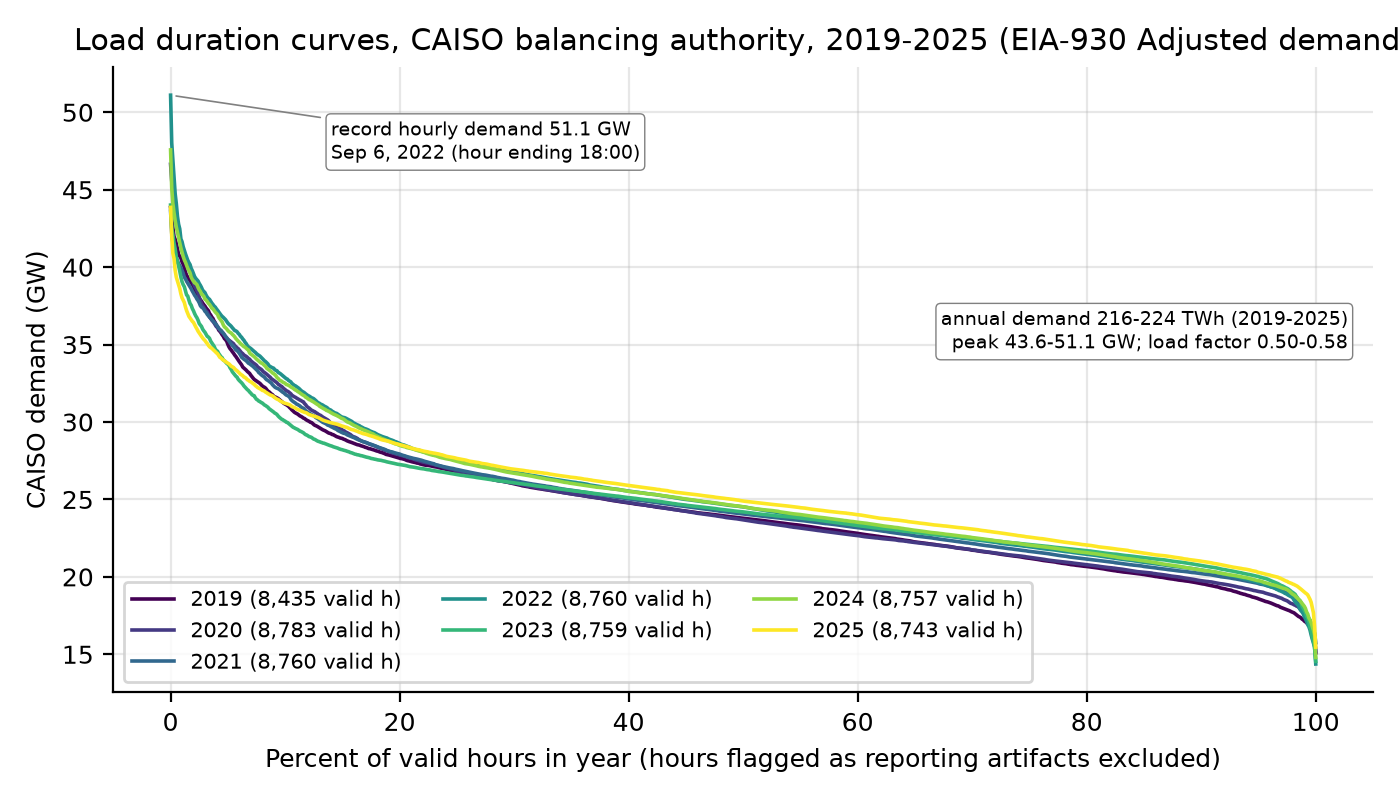

In [6]:
show("fig1_01_load_duration_curves")

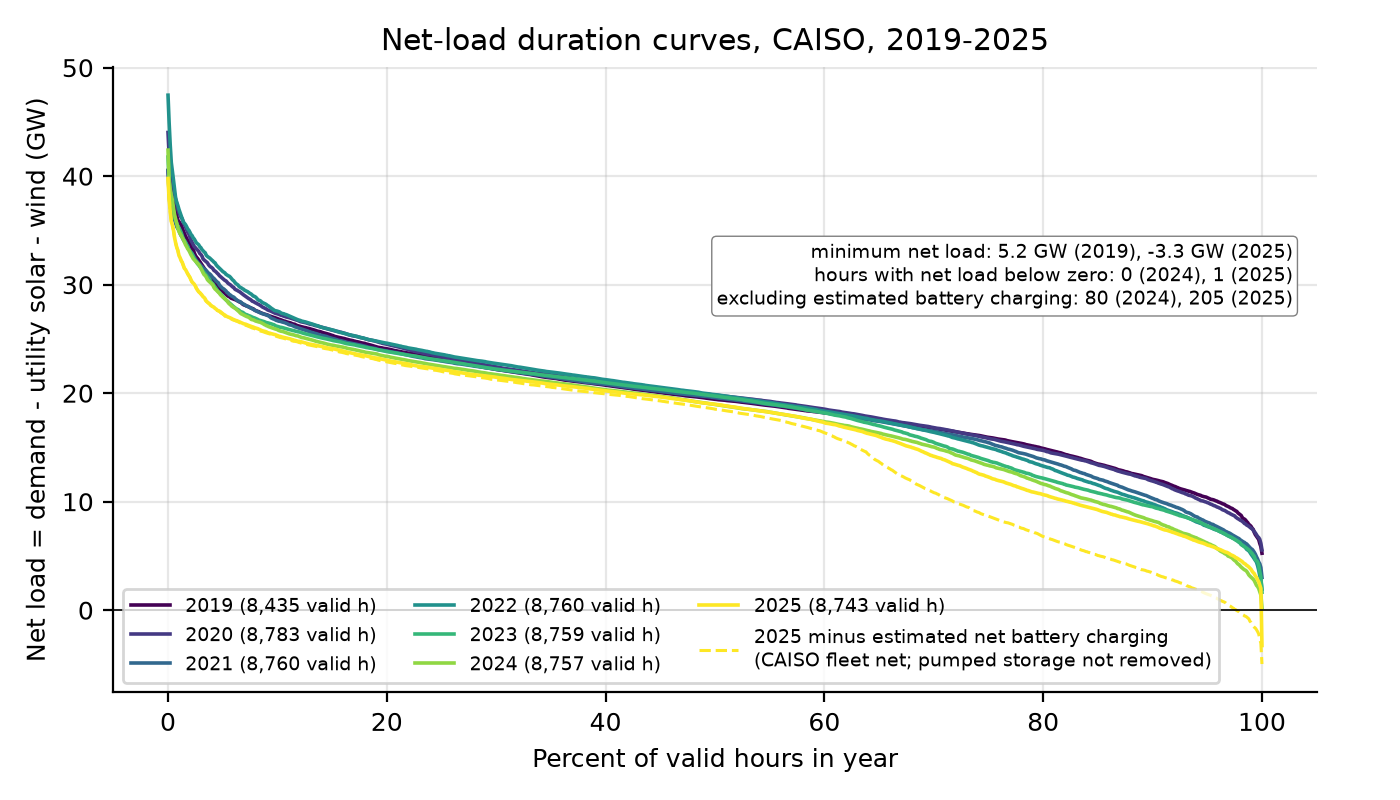

In [7]:
show("fig1_02_net_load_duration_curves")

**Reading.** The load duration curves barely move between years; the net-load duration curves fall steadily at the low end, and by 2025 the lowest-net-load hours are near or below zero, meaning utility solar and wind alone exceed CAISO demand in those hours. This is the midday surplus that later chapters treat as a resource for flexible load.

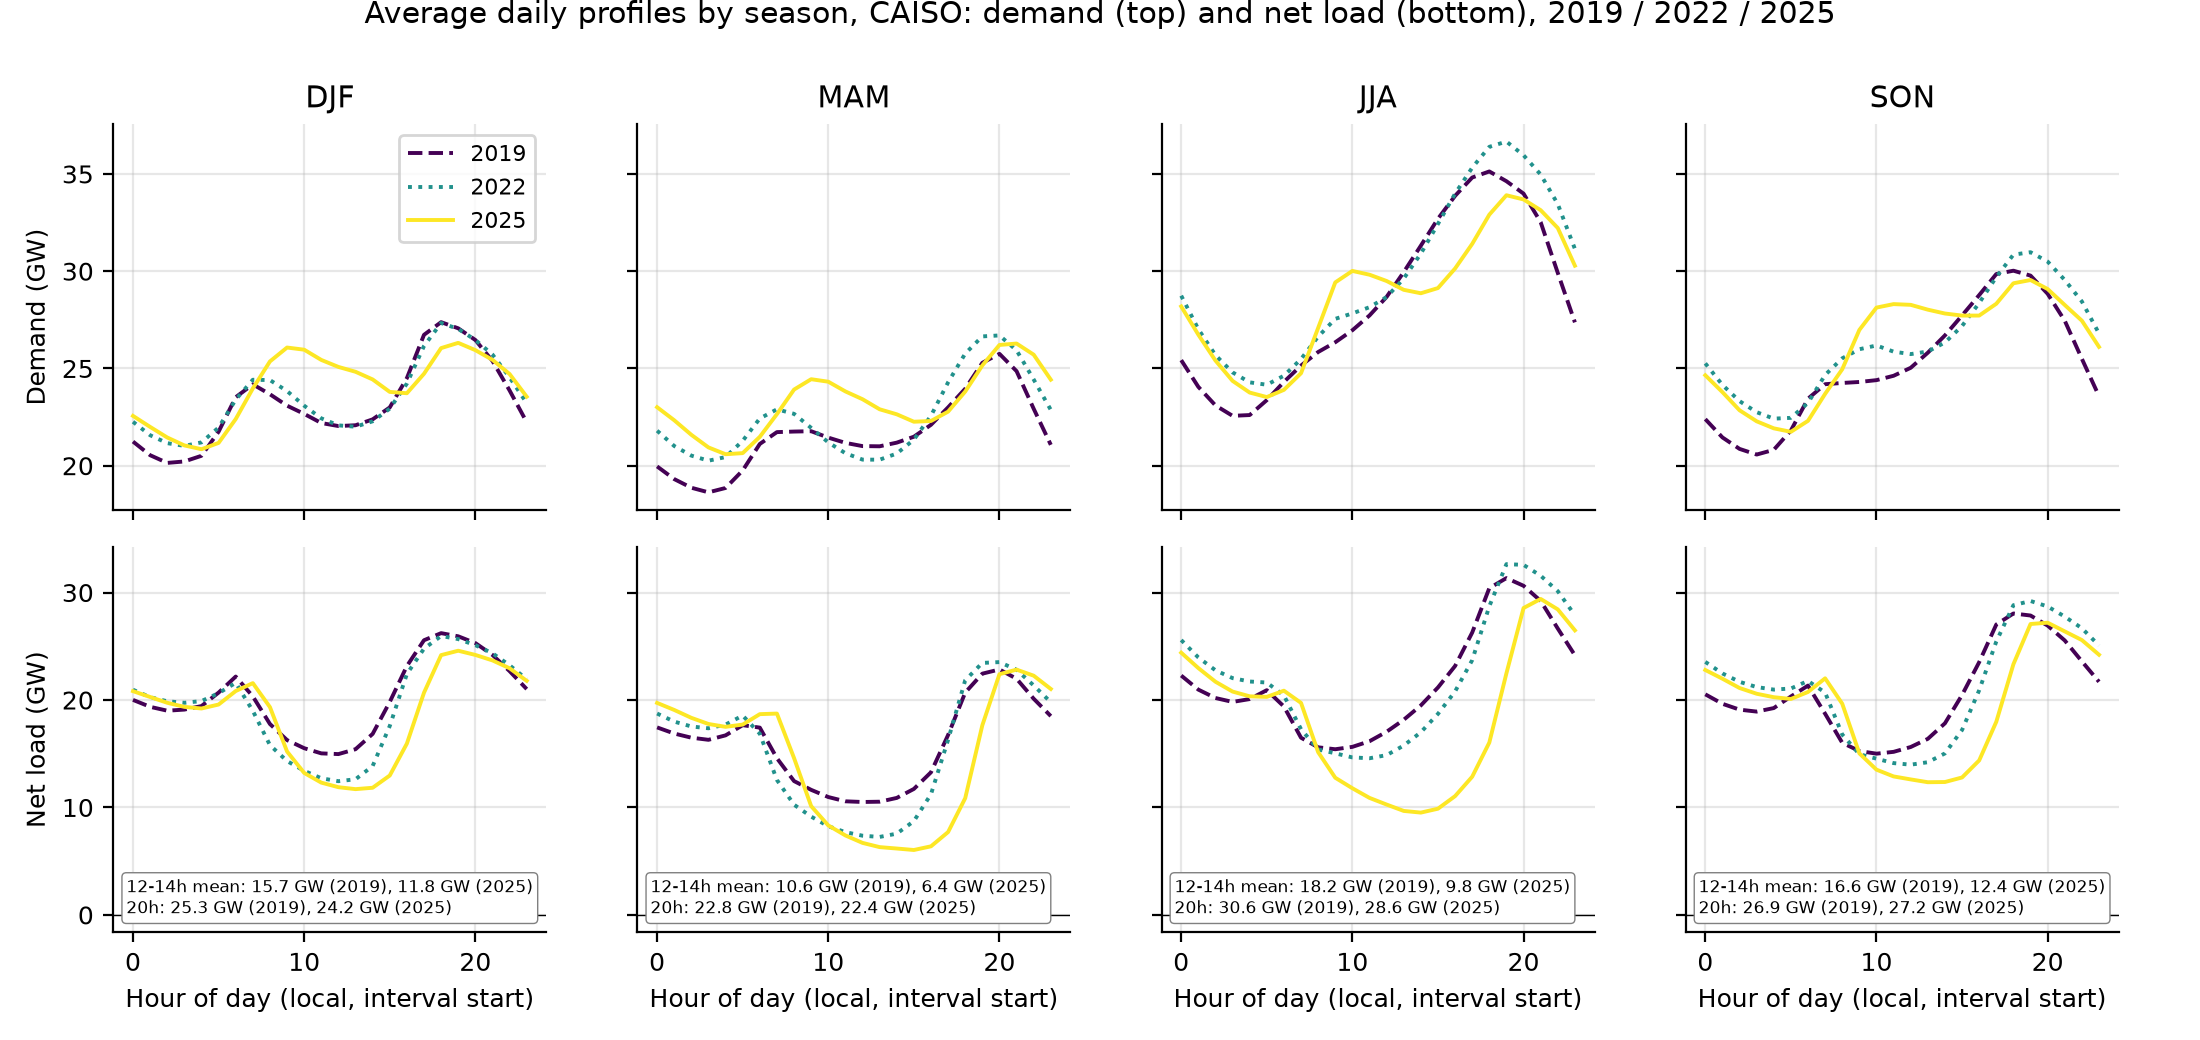

In [8]:
show("fig1_03_seasonal_daily_profiles")

**Reading.** Demand profiles (top) are similar across years; net-load profiles (bottom) show the deepening midday trough and a steeper, later evening ramp. In spring 2025 the average midday net load is about 6 GW against roughly 21 GW at 8 pm.

In [9]:
timing = table("ch1_top100_net_load_timing", index_col=0)
timing[["top100_net_load_min_MW","top100_net_load_max_MW","distinct_days","share_Jul_Sep","share_hours_17_21","median_hour","earliest_hour","latest_hour","mean_solar_MW","mean_imports_MW","mean_gas_MW"]].round(2)

,top100_net_load_min_MW,top100_net_load_max_MW,distinct_days,share_Jul_Sep,share_hours_17_21,median_hour,earliest_hour,latest_hour,mean_solar_MW,mean_imports_MW,mean_gas_MW
year,,,,,,,,,,,
2019,35560.0,40536.0,34,0.90,0.99,18.0,16,21,863.99,8536.95,18476.98
2020,36352.0,44026.0,30,0.92,0.86,18.0,14,22,1241.24,7446.00,22648.94
2021,34671.0,40495.0,42,0.92,1.00,19.0,17,21,606.74,6252.80,21046.35
2022,36583.0,47464.0,27,0.95,0.82,19.0,15,23,1243.06,7401.17,22530.15
2023,34959.0,41764.0,35,0.96,0.93,20.0,17,22,571.16,3571.73,21773.13
2024,34697.0,42403.0,37,0.91,0.79,20.0,18,23,900.78,4709.08,20851.30
2025,32328.0,39787.0,33,0.98,0.78,20.0,18,23,736.47,4550.02,17302.06


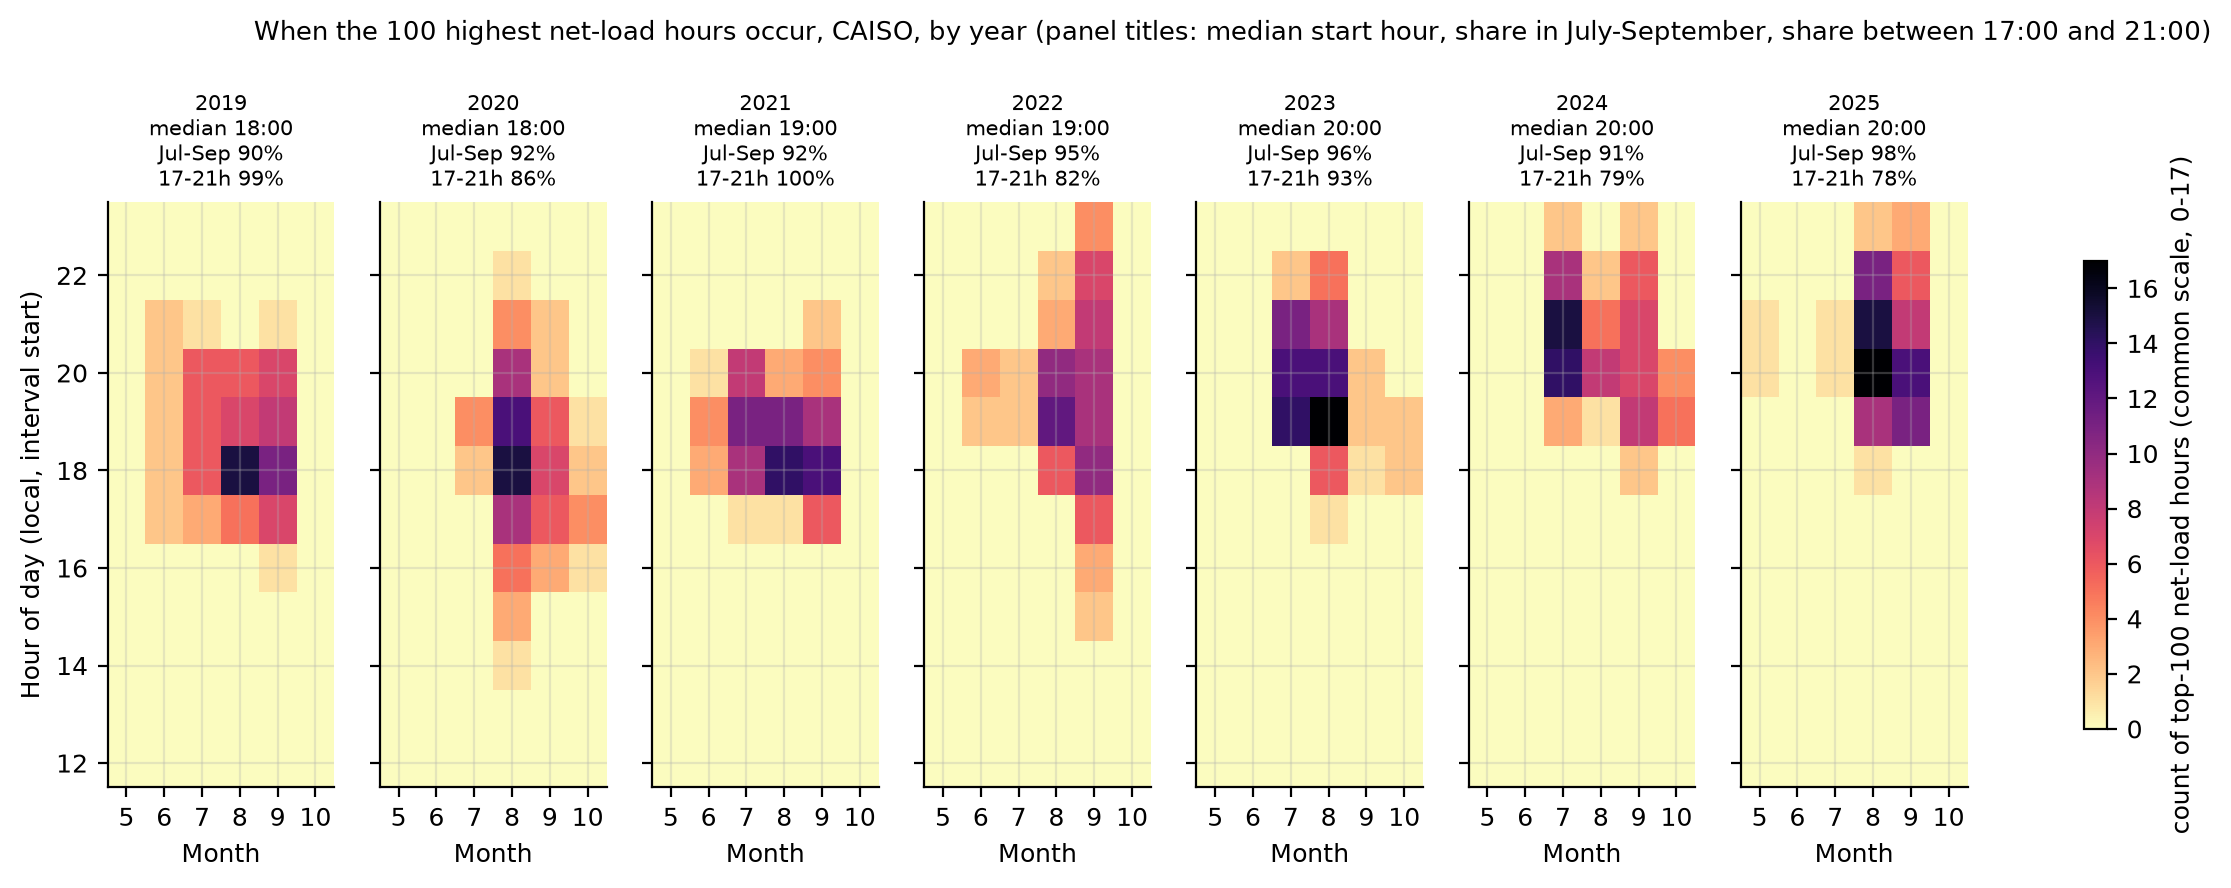

In [10]:
show("fig1_04_top100_net_load_timing")

**Reading.** The 100 highest net-load hours of each year fall almost entirely in July-September and between 5 pm and 9 pm, and their median start time has moved from 6 pm (2019-2020) to 8 pm (2023-2025). Solar contributes under 1.3 GW on average in these hours. A flat data center load therefore adds one-for-one to the hours that set capacity needs; storage and gas, not solar, serve them.

## 2. Day-ahead prices at the default load aggregation points (OASIS PRC_LMP, DAM)

OASIS serves hourly day-ahead prices from July 2023 onward (about 39 months of retention). 2024 and 2025 are complete years; 2023 covers July-December and 2026 covers January to September 22. EIA's daily ICE hub prices (NP15, SP15) extend to 2015 but are daily block averages.

In [11]:
ps = table("ch1_price_stats")
ps[ps.node.str.startswith("DLAP")][["label","year","hours","full_year","mean","median","p5","p95","min","max","hours_negative","hours_le_5","hours_ge_200","share_negative","neg_hours_10_16_share"]].round(3)

,label,year,hours,full_year,mean,median,p5,p95,min,max,hours_negative,hours_le_5,hours_ge_200,share_negative,neg_hours_10_16_share
0,PG&E DLAP,2023,4417,False,58.988,53.843,32.941,91.811,8.666,1133.611,0,0,20,0.000,0.000
1,PG&E DLAP,2024,8784,True,42.993,40.113,8.969,76.151,-33.091,648.767,190,327,67,0.022,0.879
2,PG&E DLAP,2025,8760,True,40.623,42.445,8.657,63.751,-36.810,123.014,218,337,0,0.025,0.940
3,PG&E DLAP,2026,6359,False,31.532,31.894,0.359,60.131,-14.174,217.077,294,480,2,0.046,0.867
4,SCE DLAP,2023,4417,False,57.915,52.527,10.973,107.608,-12.469,1275.330,53,130,57,0.012,0.887
5,SCE DLAP,2024,8784,True,34.020,36.991,-20.000,67.704,-66.600,627.633,1131,1369,52,0.129,0.772
6,SCE DLAP,2025,8760,True,34.411,40.235,-8.336,60.453,-40.479,117.522,877,1109,0,0.100,0.780
7,SCE DLAP,2026,6359,False,28.665,30.340,-8.979,64.832,-17.950,210.480,890,1123,2,0.140,0.719
8,SDG&E DLAP,2023,4417,False,60.020,54.132,11.914,113.021,-11.723,1288.806,40,112,55,0.009,0.925
9,SDG&E DLAP,2024,8784,True,36.212,38.189,-17.333,72.507,-63.086,637.022,989,1227,52,0.113,0.768


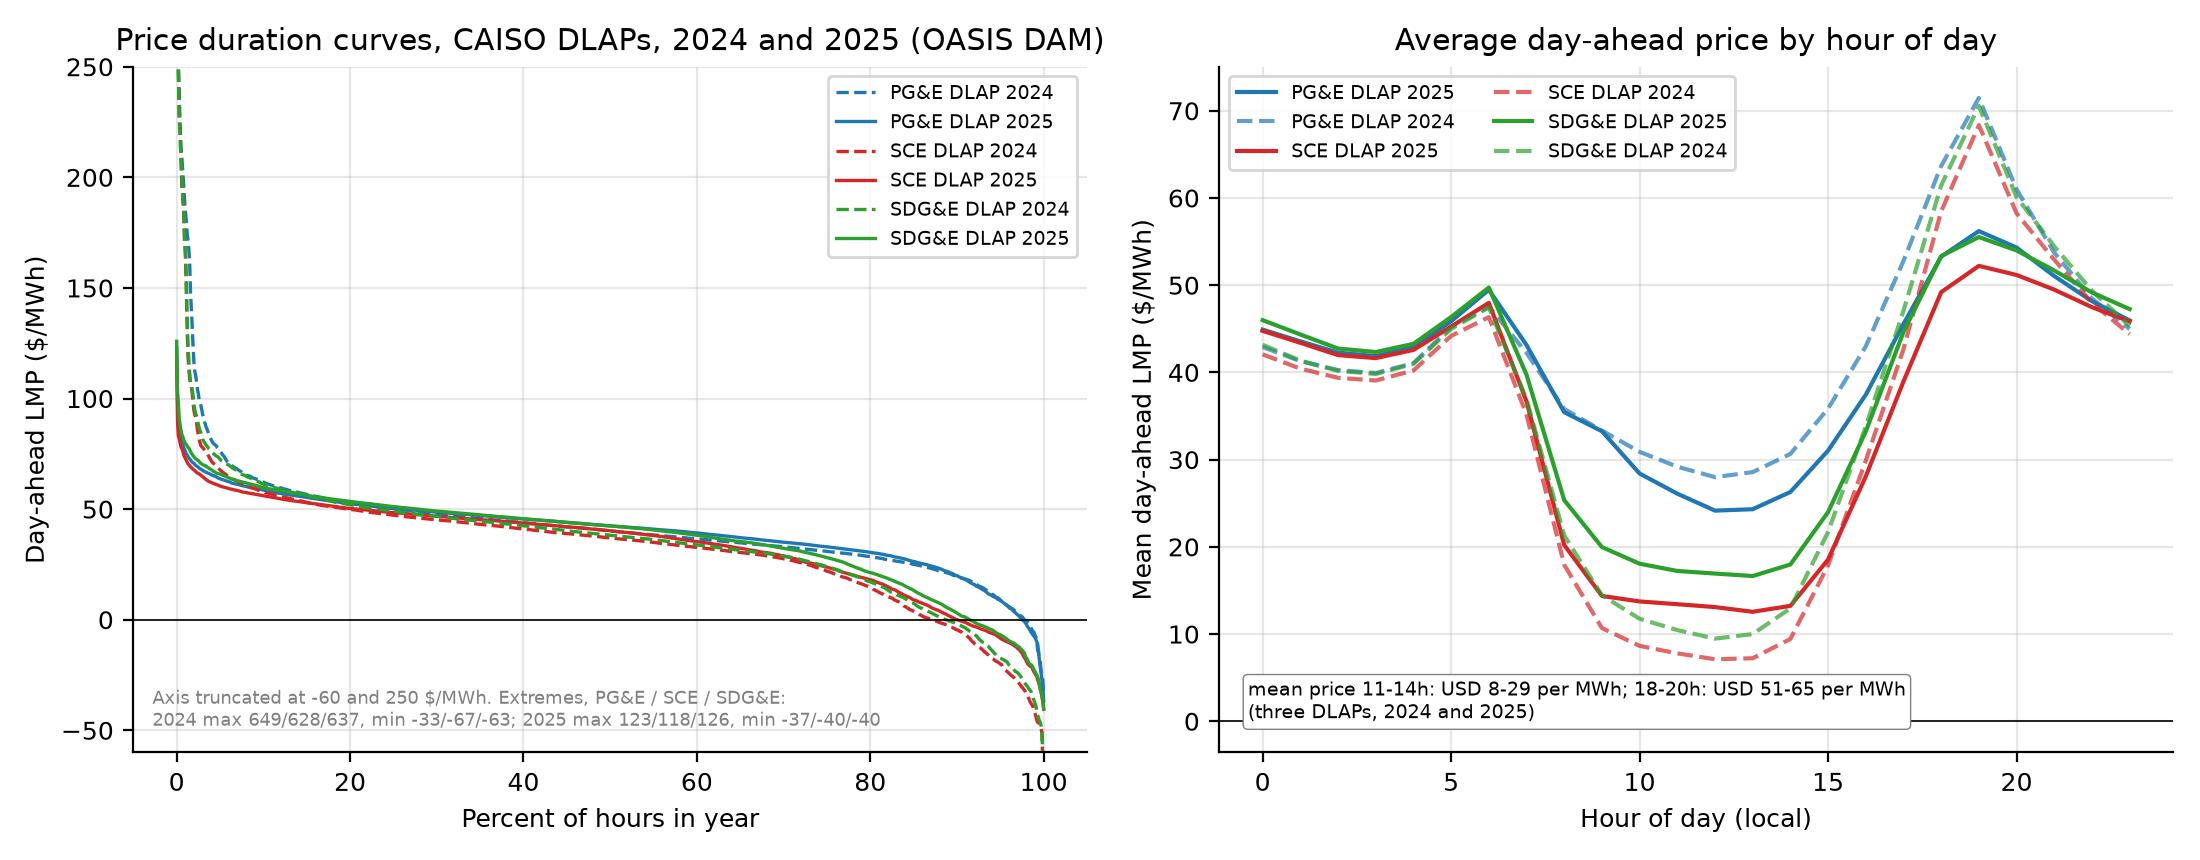

In [12]:
show("fig1_05_price_duration_and_diurnal")

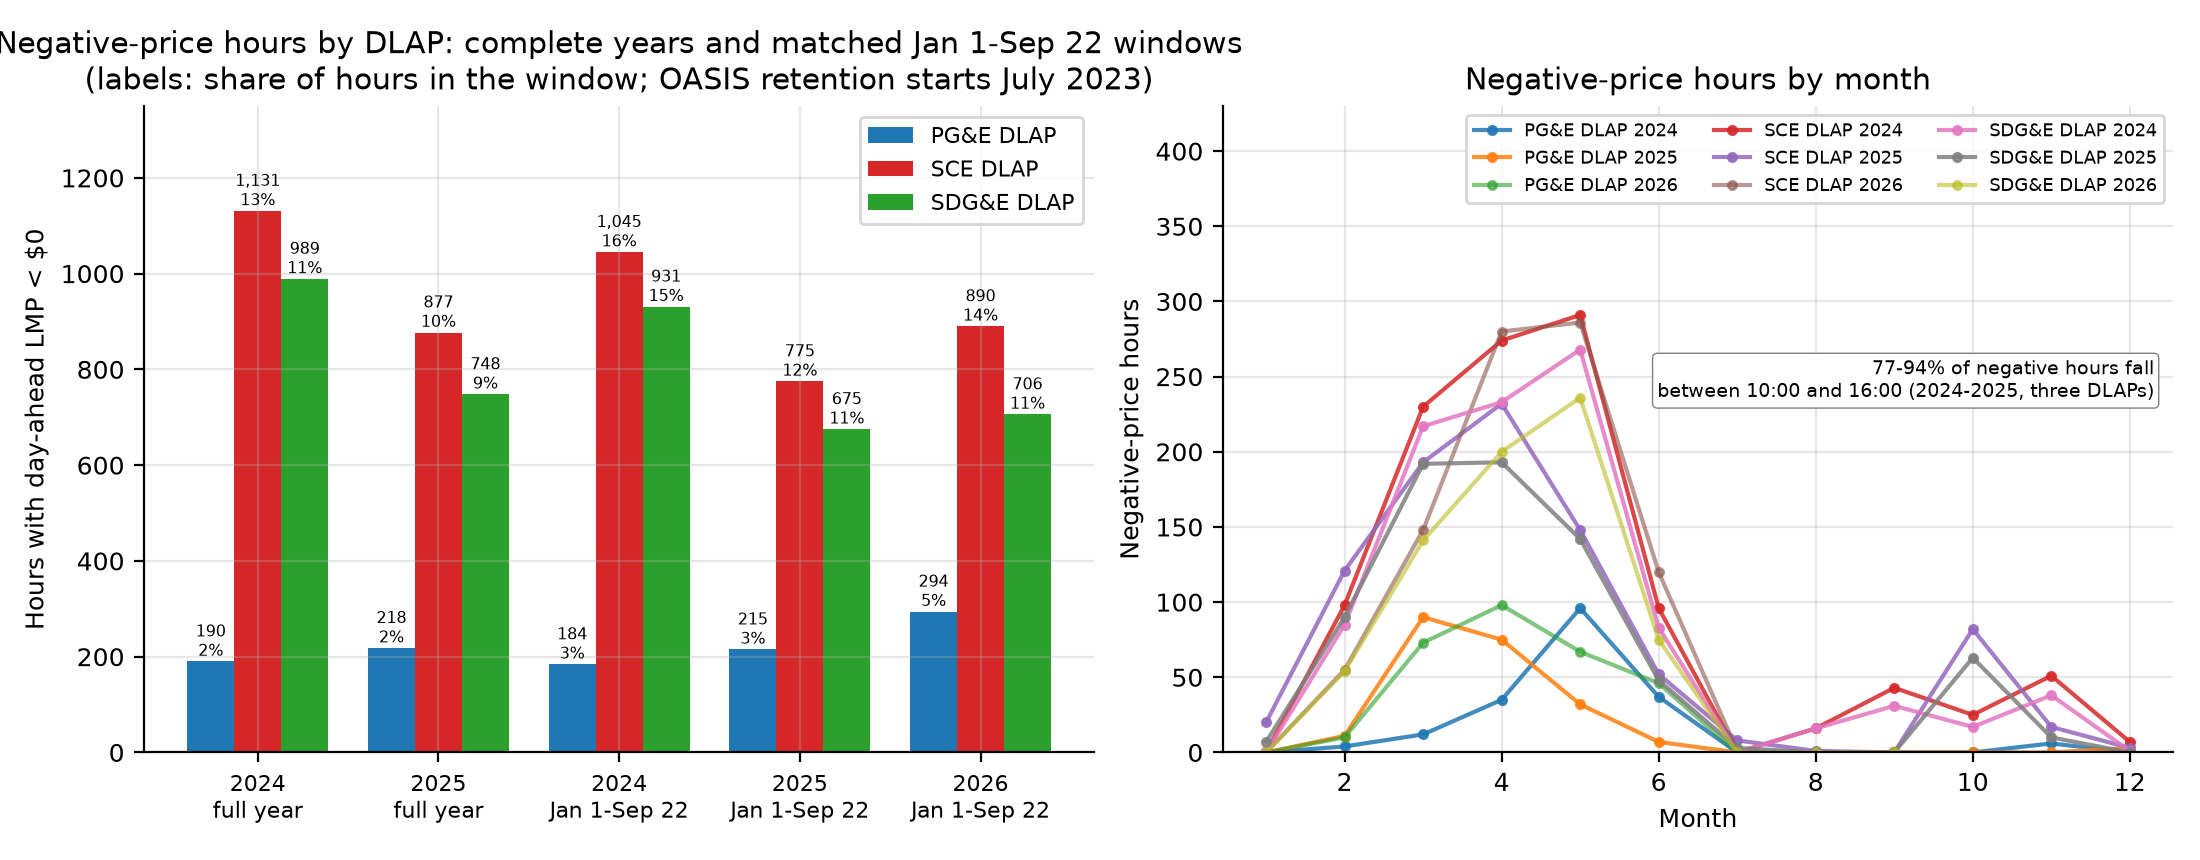

In [13]:
show("fig1_06_negative_price_hours")

In [14]:
nb = table("ch1_negative_price_hours_by_month")
nb[nb.year.isin([2024, 2025, 2026])].pivot(index="month", columns="year", values=["DLAP_PGAE-APND","DLAP_SCE-APND","DLAP_SDGE-APND"])

DLAP_PGAE-APND             DLAP_SCE-APND               DLAP_SDGE-APND              
year            2024  2025  2026          2024   2025   2026           2024   2025   2026
month                                                                                    
1                0.0   0.0   0.0           0.0   20.0    0.0            0.0    7.0    0.0
2                4.0  11.0  10.0          98.0  121.0   55.0           85.0   90.0   54.0
3               12.0  90.0  73.0         230.0  193.0  148.0          217.0  192.0  141.0
4               35.0  75.0  98.0         274.0  232.0  280.0          233.0  193.0  200.0
5               96.0  32.0  67.0         291.0  148.0  286.0          268.0  142.0  236.0
6               37.0   7.0  46.0          96.0   52.0  120.0           83.0   48.0   75.0
7                0.0   0.0   0.0           0.0    8.0    1.0            0.0    3.0    0.0
8                0.0   0.0   0.0          16.0    1.0    0.0           16.0    0.0    0.0
9                0.0   0.0   0.0          43.0    0.0    0.0           31.0    0.0    0.0
10               0.0   0.0   NaN          25.0   82.0    NaN           17.0   63.0    NaN
11               6.0   0.0   NaN          51.0   17.0    NaN           38.0   10.0    NaN
12               0.0   3.0   NaN           7.0    3.0    NaN            1.0    0.0    NaN

In [15]:
ice = table("ch1_ice_daily_hub_prices_negative_days"); ice[ice.hub.str.contains("DA")]

,hub,year,trading_days,days_wavg_negative,days_low_negative,mean_wavg,min_low
0,NP15 EZ Gen DA LMP Peak,2015,145,0,0,36.553862,28.00
1,NP15 EZ Gen DA LMP Peak,2016,126,0,0,33.468333,18.00
2,NP15 EZ Gen DA LMP Peak,2017,93,0,0,42.126064,14.75
3,NP15 EZ Gen DA LMP Peak,2018,44,0,0,79.339545,27.75
4,NP15 EZ Gen DA LMP Peak,2019,38,0,0,59.733947,17.00
5,NP15 EZ Gen DA LMP Peak,2020,38,0,0,58.533421,13.50
6,NP15 EZ Gen DA LMP Peak,2021,60,0,0,76.426167,27.00
7,NP15 EZ Gen DA LMP Peak,2022,68,0,0,107.997353,35.50
8,NP15 EZ Gen DA LMP Peak,2023,98,0,0,73.587653,15.25
9,NP15 EZ Gen DA LMP Peak,2024,82,0,0,47.711707,9.00


In [16]:
table("ch1_negative_price_hours_windows").round(1)

,window,year,node,label,hours,hours_negative,share_negative_pct
0,Jan 1-Sep 22,2024,DLAP_PGAE-APND,PG&E DLAP,6383,184,2.9
1,Jan 1-Sep 22,2024,DLAP_SCE-APND,SCE DLAP,6383,1045,16.4
2,Jan 1-Sep 22,2024,DLAP_SDGE-APND,SDG&E DLAP,6383,931,14.6
3,Jan 1-Sep 22,2025,DLAP_PGAE-APND,PG&E DLAP,6359,215,3.4
4,Jan 1-Sep 22,2025,DLAP_SCE-APND,SCE DLAP,6359,775,12.2
5,Jan 1-Sep 22,2025,DLAP_SDGE-APND,SDG&E DLAP,6359,675,10.6
6,Jan 1-Sep 22,2026,DLAP_PGAE-APND,PG&E DLAP,6359,294,4.6
7,Jan 1-Sep 22,2026,DLAP_SCE-APND,SCE DLAP,6359,890,14.0
8,Jan 1-Sep 22,2026,DLAP_SDGE-APND,SDG&E DLAP,6359,706,11.1
9,full year,2024,DLAP_PGAE-APND,PG&E DLAP,8784,190,2.2


**Reading.** Negative day-ahead prices are now routine in Southern California: the SCE aggregation point cleared below zero in 1,131 hours of 2024 and 877 hours of 2025, and 890 hours in the first 265 days of 2026; on the matched January 1 to September 22 window that is 1,045 / 775 / 890 hours (16 / 12 / 14 percent of hours), so 2026 sits between the two complete years. PG&E's point saw 190-294 hours. Three quarters or more of those hours fall between 10 am and 4 pm, concentrated in February-June. Daily block prices from ICE almost never go negative, which is why the hourly series is needed. This is the California-specific fact that matters for load flexibility: a data center able to shift or add consumption into those hours faces a zero or negative marginal energy price.

## 3. Hourly carbon intensity of CAISO demand

CAISO's Today's Outlook reports 5-minute CO2 by source including imports (metric tons per hour), with export emissions netted against imports. The indicator is CAISO's accounting total divided by CAISO demand (g CO2 per kWh, energy-weighted per year): an accounting rate for the supply serving CAISO demand, not a measured consumption footprint. Negative hours (net exports) are kept in the headline series; a floored-at-zero variant is the sensitivity. CAISO publishes a fixed 288-row clock grid per day (daylight-saving hours cannot be separated); an hour is valid with at least 6 of 12 intervals for both CO2 and demand, and all-missing hours stay missing instead of becoming zero. EIA's December 2023 gas-method warning applies to EIA-930, not to CAISO's accounting: the implied gas emission factor stays at 432-452 kg/MWh month by month across the change. eGRID's CAMX rate is a generation output rate with a different boundary.

In [17]:
cs = table("ch1_carbon_intensity_annual", index_col=0).round(1); eg = json.loads((PROCESSED / "ch1_egrid_camx_2023.json").read_text()); print(eg); cs

{'subregion': 'CAMX', 'year': 2023, 'co2_output_rate_lb_per_MWh': 436.655, 'co2_output_rate_g_per_kWh': 198.06337632235, 'co2e_output_rate_g_per_kWh': 198.76553731111, 'net_generation_TWh': 216.841822331, 'co2_Mt': 47.342486547}


,hours,hours_in_year,hours_net_co2_negative,energy_weighted_g_per_kWh,energy_weighted_floored_g_per_kWh,hourly_mean_g_per_kWh,p5_g_per_kWh,p95_g_per_kWh,min_g_per_kWh,max_g_per_kWh,co2_Mt,imports_co2_share,gas_co2_share,implied_gas_kg_per_MWh,coverage_pct
2019,8759,8760,8,256.7,256.8,254.4,109.4,360.6,-768.3,435.8,55.9,0.4,0.5,457.9,100.0
2020,8782,8784,0,277.4,277.4,274.8,131.9,367.8,41.8,424.4,60.4,0.4,0.5,445.6,100.0
2021,8759,8760,0,274.5,274.5,272.7,125.2,361.4,21.8,395.3,59.7,0.4,0.6,443.4,100.0
2022,8759,8760,13,264.4,264.4,261.5,107.7,354.8,-38.9,417.4,58.1,0.3,0.6,440.8,100.0
2023,8759,8760,19,241.9,242.0,239.0,85.1,343.8,-62.0,433.7,51.1,0.2,0.8,441.5,100.0
2024,8765,8784,374,199.4,200.7,194.8,6.9,321.9,-151.6,384.0,42.4,0.3,0.7,442.6,99.8
2025,8759,8760,425,186.3,187.7,183.4,0.7,318.9,-140.2,362.1,38.8,0.3,0.6,436.9,100.0


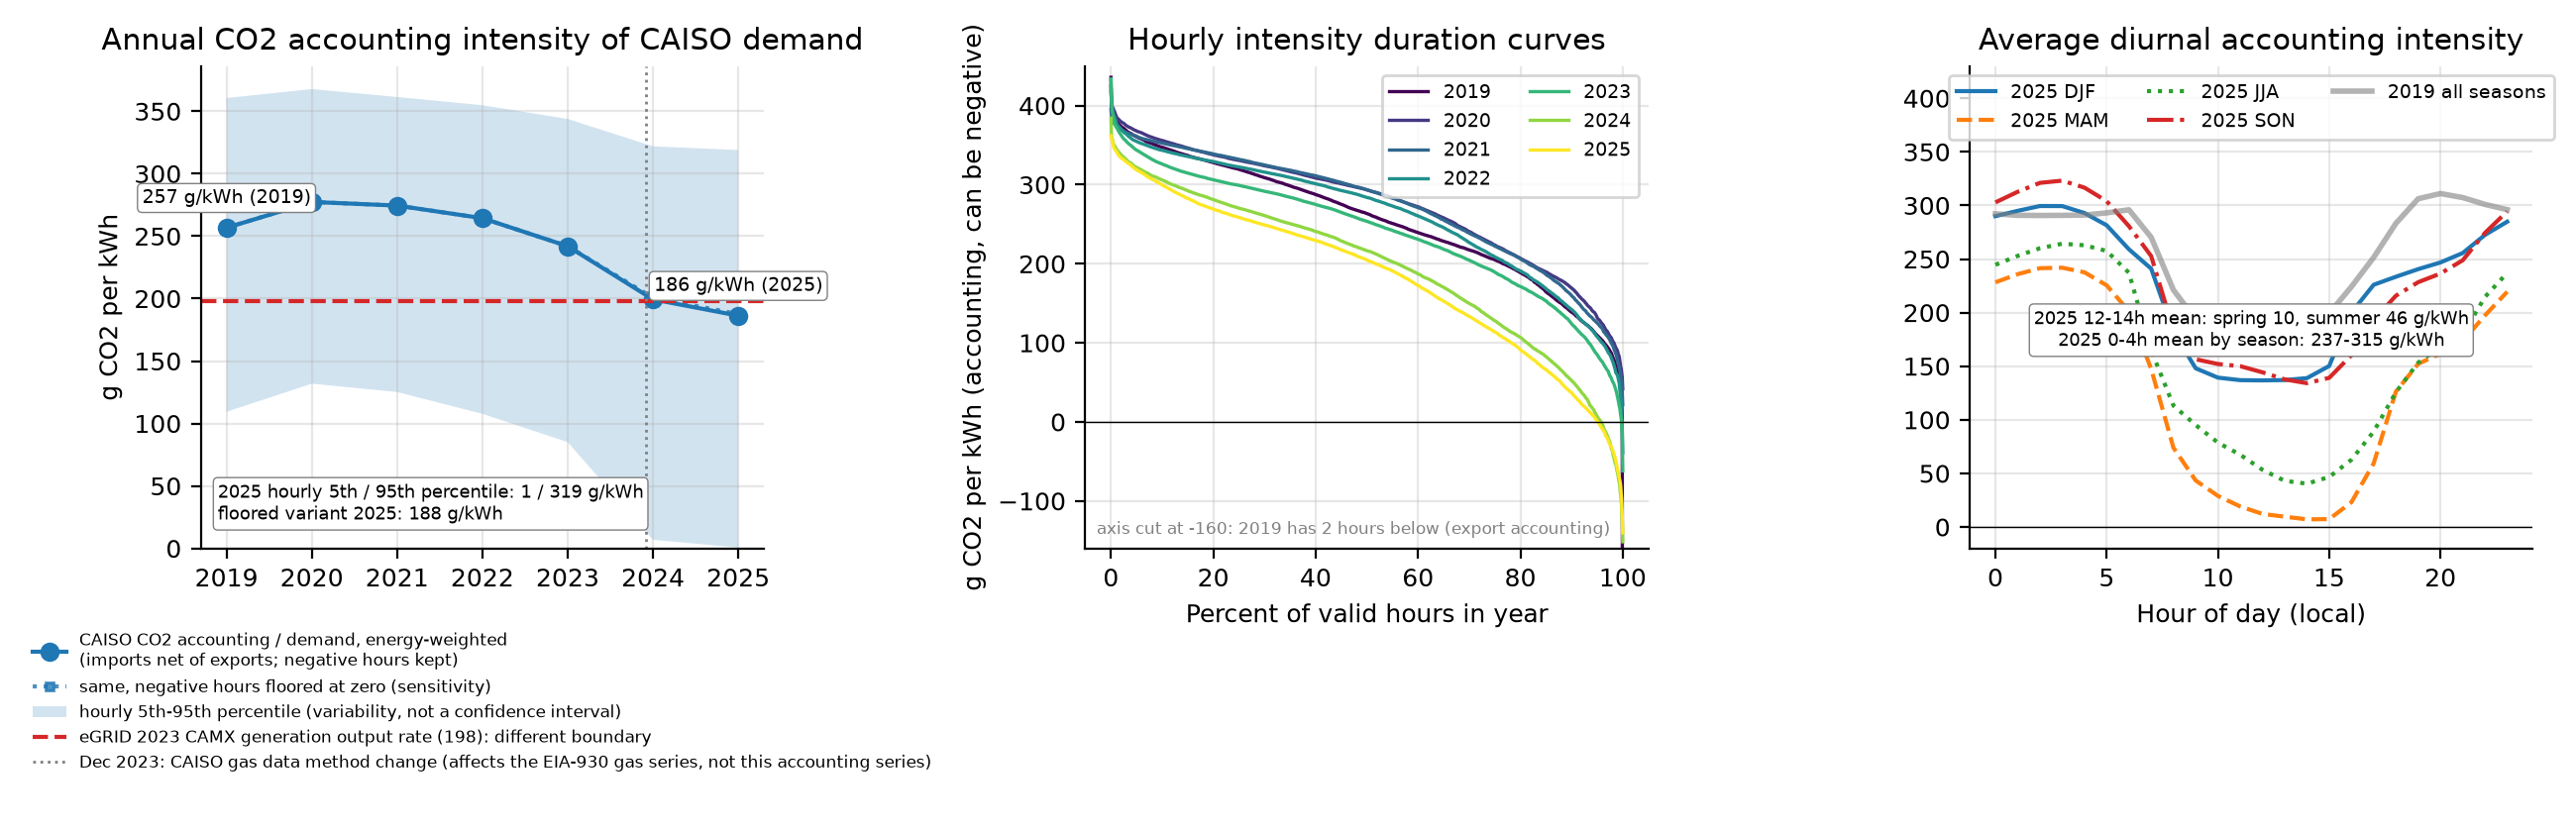

In [18]:
show("fig1_07_carbon_intensity")

In [19]:
bat = table("ch1_battery_summary", index_col=0).round(2); bat

,discharge_TWh,charge_TWh,peak_discharge_MW,peak_charge_MW,hours
year,,,,,
2019,0.05,-0.08,78.17,-85.92,8759
2020,0.06,-0.08,234.00,-202.33,8782
2021,0.83,-0.92,1362.33,-1205.92,8759
2022,2.73,-1.70,2962.50,-2142.83,8759
2023,4.34,-4.45,4780.75,-4295.42,8759
2024,8.18,-9.45,7848.75,-7163.58,8765
2025,12.29,-14.21,10707.33,-9288.83,8759


**Reading.** The accounting intensity fell from about 257 g/kWh in 2019 to 186 g/kWh in 2025 (floored variant 188), with average spring midday hours near 10 g/kWh, summer midday about 46 g/kWh, and night hours 240-315 g/kWh; coverage is 99.8 percent of calendar hours or better. eGRID's 2023 CAMX generation rate (198 g/kWh) is a single-year reference with a different boundary, lower than the 2023 accounting figure (242 g/kWh). The decline is an accounting result consistent with the solar and battery additions; an independent check against CAISO's GHG tracking reports is deferred to the supply chapter. Battery discharge grew from 0.05 TWh in 2019 to 12.3 TWh in 2025 with a 10.7 GW peak, which is what moved the net-peak hours later in the evening.

## 4. Existing data center electricity use in California: evidence and assumptions

The four items are not four comparable estimates of one quantity. A is the only statewide historical estimate (EPRI, 2023); B converts the CEC's ~1,000 MW existing peak with an assumed annual load factor; C is an illustrative count-based sensitivity (facility points x an assumed per-facility energy taken from the SVP cluster, no peak or utilization factor); D is a single-utility subset. Shares use EIA-861 retail sales (Parts A + C + D) of the matching year.

In [20]:
rs = table("ch1_ca_retail_sales_eia861"); rs.round(2)

,year,MWh_A_bundled,MWh_B_delivery_only,MWh_C_energy_only,MWh_D_adjustment,retail_sales_TWh
0,2019,183460492.0,66918218.0,66918218.0,0.0,250.38
1,2020,179450656.0,70724016.0,70724016.0,0.0,250.17
2,2021,172633325.0,74616540.0,74616540.0,0.0,247.25
3,2022,166609910.0,85259226.0,85259226.0,0.0,251.87
4,2023,152211367.0,87269085.0,87269085.0,0.0,239.48
5,2024,156099185.0,89617960.0,89617960.0,0.0,245.72


In [21]:
est = table("ch1_dc_load_estimates"); est[["method","low_TWh","central_TWh","high_TWh","low_share_pct","central_share_pct","high_share_pct"]].round(2)

,method,low_TWh,central_TWh,high_TWh,low_share_pct,central_share_pct,high_share_pct
0,"EPRI 2024 state table, 2023 consumption",9.33,9.33,9.33,3.90,3.90,3.90
1,"CEC ~1,000 MW existing peak (Dec 2025) x assum...",7.01,7.71,8.32,2.85,3.14,3.39
2,Count-based: 321 Kollar-Grady facility points ...,6.82,10.23,13.64,2.85,4.27,5.69
3,Silicon Valley Power only: 53-60% of SVP 2023 ...,2.37,2.46,2.69,0.99,1.03,1.12


In [22]:
for _, r in est.iterrows(): print(f"- {r.method}\n    basis: {r.basis}\n    sources: {r.source}\n")

- EPRI 2024 state table, 2023 consumption
    basis: 9,331,619 MWh = 3.70% of state consumption in 2023 (EPRI Table, p.13 and Appendix p.28); share below uses EIA-861 2023 retail sales
    sources: epri_powering_intelligence_2024

- CEC ~1,000 MW existing peak (Dec 2025) x assumed annual load factor 0.80-0.95
    basis: ~1,000 MW existing data center peak demand as of Dec 2025 (CEC methodology memo, Apr 2026, pp. 2 and 18); the annual load factor is an assumption bracketed by the CEC's daily load-factor profiles (75-100% of annual max), not a measured annual value; share uses the latest EIA-861 year
    sources: cec_dc_methodology_memo_2026; cec_prelim_dc_forecast_2025

- Count-based: 321 Kollar-Grady facility points x assumed energy per facility
    basis: 321 Kollar-Grady facility points inside California (102 within 12 km of Santa Clara); the Epoch AI snapshot has no California observation (0 sites), which is a coverage limit, not a count of zero; assumed annual energy per facility 

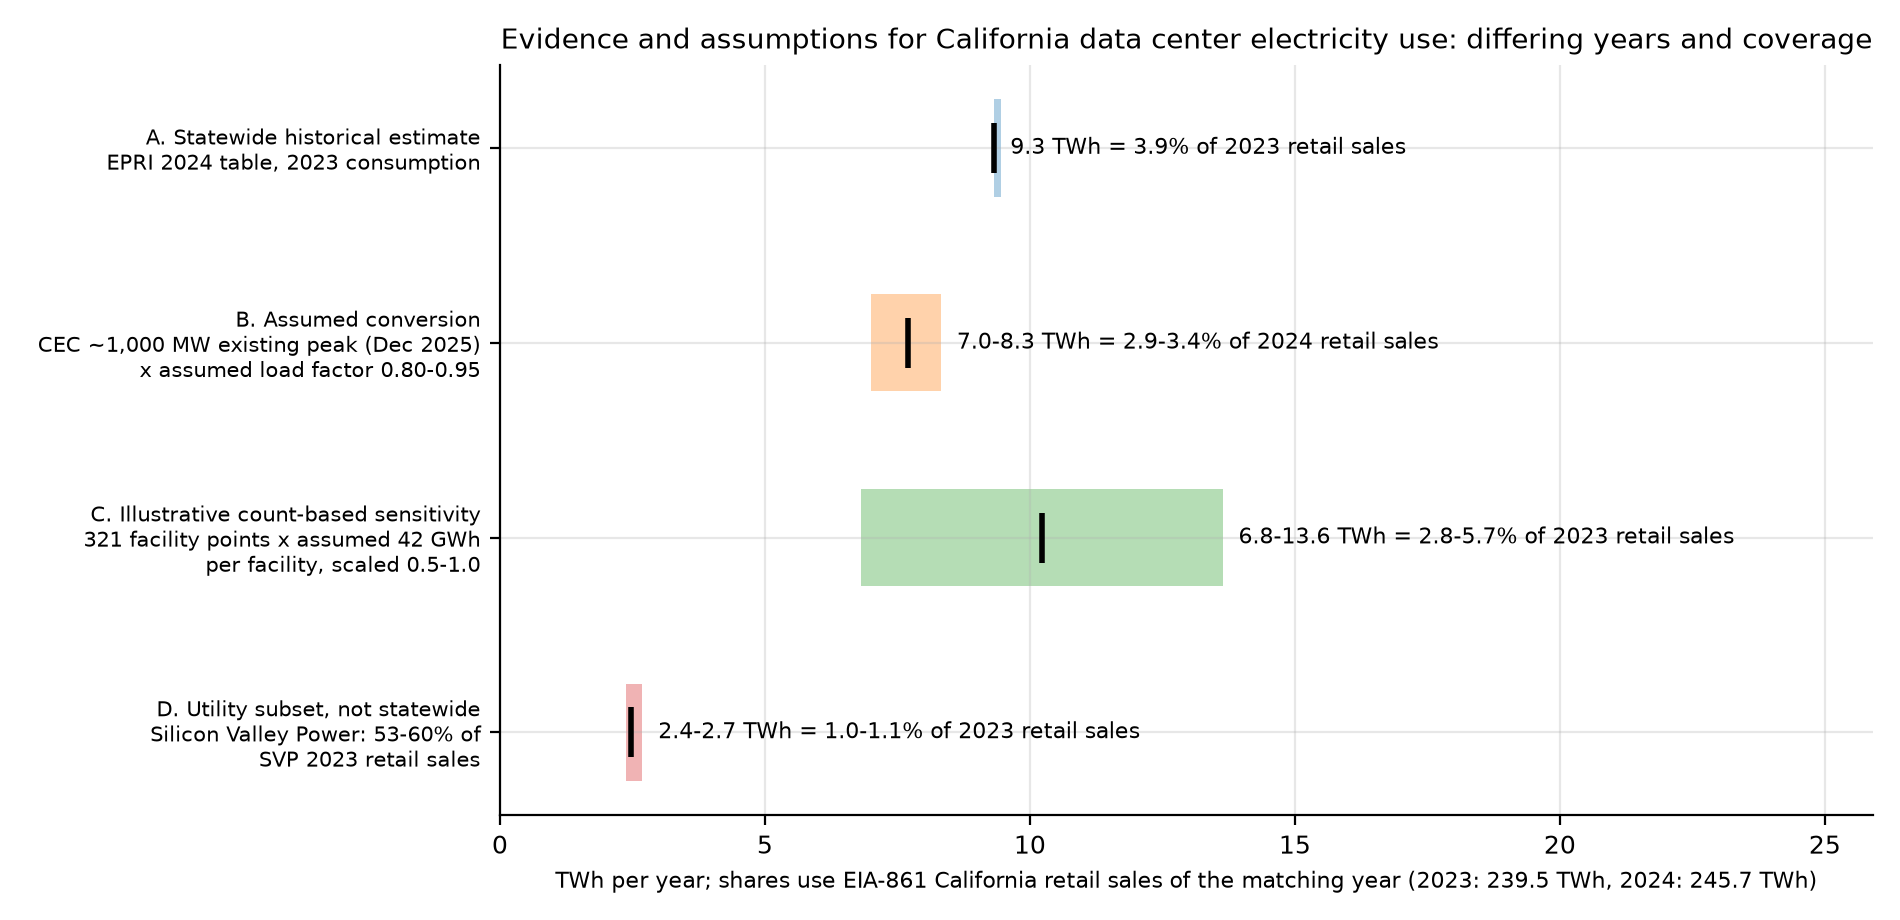

In [23]:
show("fig1_08_existing_dc_load_estimates")

In [24]:
svp = table("ch1_svp_fact_sheets"); bu = json.loads((PROCESSED / "ch1_bottom_up_inputs.json").read_text()); print(bu); svp.round(2)  # peak, load factor, retail sales and supply from the SVP fact sheets (report Table: Silicon Valley Power fact-sheet series)

{'n_california_facilities_kollar_grady': 321, 'n_within_12km_of_santa_clara': 102, 'n_epoch_california_sites': 0, 'svp_data_centers': 58, 'svp_dc_energy_GWh': 2463.7837724500005, 'avg_energy_GWh_per_facility_svp_anchor': 42.479030559482766, 'avg_load_MW_per_facility_svp_anchor': 4.849204401767439, 'size_scale_low_central_high': [0.5, 0.75, 1.0], 'low_TWh': 6.817884404796984, 'central_TWh': 10.226826607195477, 'high_TWh': 13.635768809593968}


,fact_sheet_year,peak_MW,load_factor,electric_accounts,retail_sales_GWh,supply_GWh,energy_GWh_est
0,2017,586.6,0.72,NaN,NaN,3726.77,3725.50
1,2018,526.2,0.80,55383.0,NaN,3694.31,3692.22
2,2019,587.8,0.72,55116.0,NaN,3729.35,3727.97
3,2020,586.3,0.75,58701.0,3741.01,3850.80,3851.99
4,2021,594.8,0.79,57557.0,4028.52,4133.86,4131.89
5,2022,693.9,0.74,59803.0,4414.16,4516.18,4516.37
6,2023,669.2,0.78,60685.0,4479.61,4587.76,4590.10


**Reading.** The statewide estimate and the assumed conversion agree: EPRI's 2023 figure (9.3 TWh, 3.9 percent of 2023 retail sales; 3.70 percent on EPRI's own denominator) and the CEC's ~1,000 MW existing peak converted at an assumed 0.80-0.95 annual load factor (7.0-8.3 TWh, 2.9-3.4 percent of 2024 sales). The count-based sensitivity (321 Kollar-Grady facility points x an assumed 42 GWh per facility from the SVP cluster, scaled 0.5-1.0) gives 6.8-13.6 TWh (2.8-5.7 percent) and is an assumption set, not a measurement; the Epoch snapshot's lack of California observations is a coverage limit. Silicon Valley Power's 58 data centers at 53-60 percent of SVP's 4.48 TWh of 2023 retail sales are 2.4-2.7 TWh, about one percent of statewide sales. The defensible statement is: existing data centers used about 3 to 4 percent of California's electricity in 2023-2025, no metered statewide total exists, and one municipal utility hosts roughly a quarter to a third of it. Against this roughly 1 GW of existing peak, the CEC's December 2025 energization requests located in California total 20,677 MW (23,277 MW including VEA's 2,600 MW in Nevada), a ratio of about 21 that is the subject of chapter 2.

## 5. Institutional context (documented in `report/sections/02_current_status.tex`)

- **January 2026 single forecast set agreement.** The CEC adopted the CED 2025-2045 forecast set on January 21, 2026 with three data center scenarios, but the joint CEC-CPUC-CAISO agreement (TN 268288, updated April 15, 2026 as TN 269506) directs that CPUC IRP and CAISO bulk-system studies for the 2026-2027 and 2027-2028 transmission planning cycles continue to use the 2024 IEPR planning forecast, and that 2027 resource adequacy requirements use the 2025 IEPR forecast without known loads. Only local transmission studies use the 2025 IEPR local reliability forecast with known loads. Stated rationale: "manages volatility and promotes stability" and gives staff "additional time to collect and review historical data, observe the impacts of known loads, data centers" (TN 269506, pp. 7-8).
- **PG&E pipeline statements.** About 1.5 GW in final engineering or construction (Feb 2025 IEPR workshop, TN 261964); 10 GW pipeline over ten years with 17 projects of about 1.5 GW in final engineering for 2026-2030 (press release, July 31, 2025); "over 12 gigawatts" (Q2 2026 Form 8-K). PG&E has filed a confidentiality request for its project-level data center data every month since August 2025.
- **SCE statements.** Existing data center demand 80 MW with 200 MW near-term and 400 MW mid-term growth (Feb 2025 IEPR workshop, TN 261975); public project database of January 29, 2026 (TN 268459): 115 entries, 8,298 MW requested peak, of which 76 MW in signed agreements, 3,314 MW in applications, 1,773 MW in inquiries and 3,137 MW already canceled; the CEC's summer 2025 tally for SCE was 5,828 MW.
- **CPUC large-load proceedings (verified).** Rulemaking R.26-04-009 on Advanced Electric Rate Design (issued April 10, 2026) will "consider rate design issues for data centers and other large load customers" in coordination with the SB 57 assessment due January 1, 2027. SB 57 (Padilla) was chaptered October 11, 2025 (Stats. 2025, ch. 647). SB 886 (Padilla), the California Technology Innovation and Ratepayer Protection Act, was chaptered September 21, 2026 and requires the CPUC to establish tariffs or update electric rules for participating large customers by January 1, 2028 that prevent stranded costs or cost shifts to other customers. AB 222 was held in Senate Appropriations on August 29, 2025. The CPUC approved interim PG&E Electric Rule 30 for transmission-level service on July 24, 2025.
